# 5 · How sure are we, and what should we measure next?

A discovered equation is only useful with an honest statement of confidence and a plan to reduce the remaining
uncertainty. `eqdisc.assess` produces, for any candidate model and using public data only:

* **per-term evidence**: bootstrap coefficient intervals, and ΔBIC for removing each term or adding others. It uses
  *weak-form* statistics on noisy, coarse or PDE data, so noisy derivatives do not bias it;
* **competing models** the data cannot rule out, and whether the remaining error is at the **noise floor**;
* **sensitivity**: which uncertain coefficients actually move predictions, and the **predictability horizon**;
* **coverage**: where in state space the data live, which shows the extrapolation risk;
* **experiment design**: simulate every plausible model from candidate initial conditions and rank them by how much the
  models *disagree* relative to the noise (a cheap Bayesian-OED proxy). It also reports which coefficient each
  experiment would pin down;
* **questions for the scientist**, which the agent asks at its human-in-the-loop checkpoint.

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(ROOT); sys.path.insert(0, ROOT)
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from IPython.display import display, Markdown, Math
import sympy as sp
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
from eqdisc import toolbox as tb, coordinates as co, plots, solvers
from eqdisc.evaluate import evaluate, load
from eqdisc.datagen import generate, add_noise, simulate, NOISE_TYPES
from eqdisc.systems import SYSTEMS

def show_eqs(rhs, title=None):
    """Pretty-print a model {var: expr} as LaTeX."""
    if title: display(Markdown(f"**{title}**"))
    for v, e in rhs.items():
        names = list(rhs) + ["t", "x"] + [f"{v}_{'x'*k}" for k in range(1, 5)]
        expr = solvers.parse(e, names) if isinstance(e, str) else e
        expr = expr.xreplace({a: sp.Float(float(a), 3) for a in expr.atoms(sp.Float)})
        display(Math(rf"\dot{{{sp.latex(sp.Symbol(v))}}} = {sp.latex(expr)}"))

def scorecard(dataset, rhs, label=""):
    r = evaluate(dataset, {"rhs": rhs}, reveal=True)
    return {"model": label, "score": round(r["score"], 2), "vf_nrmse": f"{r['vf_nrmse']:.2e}",
            "rollout_nrmse": f"{r['rollout_nrmse']:.2e}", "terms": r["n_terms"], "F1": round(r["f1"], 2),
            "coef_err": None if r["coef_rel_err"] is None else round(r["coef_rel_err"], 3)}

from IPython.display import Image
from eqdisc.assess import assess, brief_markdown

## 5.1 Right vs. wrong models get different confidence
Same data (Lorenz, 5% noise). One model is correct; one is missing the −y term in dy/dt.

In [2]:
d = generate("lorenz", noise=0.05, plot=False); m, D = load(d)
right = {"x": "-10*x + 10*y", "y": "28*x - y - x*z", "z": "x*y - 2.667*z"}
wrong = {"x": "-10*x + 10*y", "y": "28*x - x*z", "z": "x*y - 2.667*z"}
A = {k: assess(m, D, r) for k, r in [("correct", right), ("missing -y", wrong)]}
pd.DataFrame([{"model": k, "confidence": a["confidence"]["level"], "reasons": " | ".join(a["confidence"]["reasons"])}
              for k, a in A.items()])

,model,confidence,reasons
0,correct,high,all terms significantly non-zero (bootstrap 90...
1,missing -y,low,all terms significantly non-zero (bootstrap 90...


In [3]:
display(Markdown(brief_markdown(A['missing -y'])))

### Confidence: **LOW**
- all terms significantly non-zero (bootstrap 90% CIs exclude 0)
- data favour adding: y to dy/dt (dBIC -85.6), y*z to dy/dt (dBIC -80.8)
- held-out rollout stays within 30% error for 23% of the horizon

### Per-term evidence
| eq | term | coef | 90% CI | significant | dBIC if removed |
|---|---|---|---|---|---|
| dx/dt | `x` | -9.91955 | [-9.976, -9.856] | True | 1070.0 |
| dx/dt | `y` | 9.93712 | [9.875, 9.992] | True | 1110.0 |
| dy/dt | `x` | 25.6612 | [25.53, 25.77] | True | 1150.0 |
| dy/dt | `x*z` | -0.953416 | [-0.9574, -0.9484] | True | 1190.0 |
| dz/dt | `z` | -2.65828 | [-2.668, -2.649] | True | 1290.0 |
| dz/dt | `x*y` | 0.997973 | [0.9944, 1.001] | True | 1430.0 |

**Competing models.** weak-form BIC: every single-term addition is penalised and every removal strongly rejected: the structure is well determined

**Predictability horizon:** 2.3 (the plausible models agree (within 3x noise) up to this time from the held-out initial state).
**Most sensitive uncertain coefficient:** `x*z` in dy/dt: its CI moves predictions by 74.1 x noise.

### Recommended next experiments
| # | experiment | discrimination score | x existing data | pins down | separates models |
|---|---|---|---|---|---|
| 1 | start at (8.89, 17.1, 37.3) | 85.5 | 1.46 | x*z in dy/dt (x4.5); x in dy/dt (x2.89); x*y in dz/dt (x2.47) |  |
| 2 | start at (-21.5, -29.5, 53.3) *outside current data range* | 84.6 | 1.44 | x*z in dy/dt (x6.23); x in dx/dt (x3.6); x*y in dz/dt (x3.04) |  |
| 3 | start at (21.5, 5.03, 60.1) *outside current data range* | 84.0 | 1.43 | x*z in dy/dt (x6.05); x in dx/dt (x3.69); x*y in dz/dt (x3.65) |  |
| 4 | start at (26.9, 8.13, 55.5) *outside current data range* | 83.0 | 1.41 | x*z in dy/dt (x6.26); x*y in dz/dt (x4.1); x in dy/dt (x3.49) |  |
| 5 | start at (-18.4, -38.7, 33.9) *outside current data range* | 82.8 | 1.41 | x*z in dy/dt (x5.48); x*y in dz/dt (x3.57); x in dx/dt (x3.19) |  |

### Questions for you
- The data favour adding y to dy/dt (dBIC -85.6). Is there a mechanism for it, or could it be an artefact (sensor drift, forcing, unmodelled coupling)?
- The data favour adding y*z to dy/dt (dBIC -80.8). Is there a mechanism for it, or could it be an artefact (sensor drift, forcing, unmodelled coupling)?
- Is any combination of the variables conserved by design (mass, energy, population)? That constraint would remove ambiguity.
- Can you run an experiment starting from [8.888550159322818, 17.142452703022187, 37.25062819938973]? It is predicted to be the most informative (score 85.5), mainly about x*z in dy/dt, x in dy/dt.

## 5.2 A PDE: KdV at 5% noise, coarse time sampling

In [4]:
d = generate("kdv", noise=0.05, dt_mult=2, plot=False); m, D = load(d)
a_kdv = assess(m, D, {"u": "-6.007*u*u_x - 1.0013*u_xxx"})
print("statistics basis:", a_kdv["statistics_basis"])
display(Markdown(brief_markdown(a_kdv)))

statistics basis: weak form (integrated against test functions; no noisy derivatives)


### Confidence: **HIGH**
- all terms significantly non-zero (bootstrap 90% CIs exclude 0)
- no single added term is supported by the data
- held-out rollout stays within 30% error for 100% of the horizon

### Per-term evidence
| eq | term | coef | 90% CI | significant | dBIC if removed |
|---|---|---|---|---|---|
| du/dt | `u_xxx` | -1.00131 | [-1.006, -0.9969] | True | 1570.0 |
| du/dt | `u*u_x` | -6.00707 | [-6.015, -6.0] | True | 2390.0 |

**Competing models.** weak-form BIC: every single-term addition is penalised and every removal strongly rejected: the structure is well determined

**Predictability horizon:** 10.0 (the plausible models agree (within 3x noise) up to this time from the held-out initial state).
**Most sensitive uncertain coefficient:** `u_xxx` in du/dt: its CI moves predictions by 0.461 x noise.

### Recommended next experiments
| # | experiment | discrimination score | x existing data | pins down | separates models |
|---|---|---|---|---|---|
| 1 | same initial profile as the last trajectory, amplitude x3.0 | 0.966 | None | u_xxx in du/dt (x16.3); u*u_x in du/dt (x6.74) |  |
| 2 | single Fourier mode k=6 (wavelength L/6), data amplitude | 0.578 | None | u_xxx in du/dt (x77.0); u*u_x in du/dt (x3.5) |  |
| 3 | same initial profile as the last trajectory, amplitude x2.0 | 0.381 | None | u*u_x in du/dt (x6.89); u_xxx in du/dt (x5.4) |  |
| 4 | same initial profile as the last trajectory, amplitude x1.5 | 0.209 | None | u_xxx in du/dt (x4.03); u*u_x in du/dt (x1.5) |  |
| 5 | single Fourier mode k=3 (wavelength L/3), data amplitude | 0.186 | None | u*u_x in du/dt (x81.2); u_xxx in du/dt (x35.1) |  |

### Questions for you
- Can you run an experiment starting from same initial profile as the last trajectory, amplitude x3.0? It is predicted to be the most informative (score 0.966), mainly about u_xxx in du/dt, u*u_x in du/dt.

## 5.3 Where to measure next: the pendulum
The damping coefficient is the most uncertain influential parameter under red noise. The experiment design looks for initial conditions where the plausible models (coefficients drawn from their intervals) diverge most. Below, grey = existing data, stars = top recommended starting points, and coloured lines = predictions of different plausible models from the best one.

### Confidence: **MEDIUM**
- all terms significantly non-zero (bootstrap 90% CIs exclude 0)
- no single added term is supported by the data
- held-out rollout stays within 30% error for 28% of the horizon

### Per-term evidence
| eq | term | coef | 90% CI | significant | dBIC if removed |
|---|---|---|---|---|---|
| dtheta/dt | `omega` | 0.9952 | [0.9866, 1.003] | True | 1160.0 |
| domega/dt | `sin(theta)` | -9.794 | [-9.843, -9.733] | True | 1320.0 |
| domega/dt | `omega` | -0.1059 | [-0.1335, -0.08332] | True | 9.46 |

**Predictability horizon:** 6.24 (the plausible models agree (within 3x noise) up to this time from the held-out initial state).
**Most sensitive uncertain coefficient:** `omega` in domega/dt: its CI moves predictions by 6.44 x noise.

### Recommended next experiments
| # | experiment | discrimination score | x existing data | pins down | separates models |
|---|---|---|---|---|---|
| 1 | start at (0.699, -6.12) *outside current data range* | 93.1 | 2.82 | sin(theta) in domega/dt (x40.9); omega in dtheta/dt (x20.4); omega in domega/dt (x18.4) |  |
| 2 | start at (-0.283, 7.88) *outside current data range* | 92.6 | 2.8 | sin(theta) in domega/dt (x26.0); omega in domega/dt (x18.1); omega in dtheta/dt (x16.7) |  |
| 3 | start at (-0.0788, 9.15) *outside current data range* | 92.5 | 2.8 | sin(theta) in domega/dt (x28.3); omega in dtheta/dt (x20.4); omega in domega/dt (x18.0) |  |
| 4 | start at (-1.32, 8.51) *outside current data range* | 92.2 | 2.79 | sin(theta) in domega/dt (x22.8); omega in dtheta/dt (x19.7); omega in domega/dt (x17.9) |  |
| 5 | start at (2.68, -8.84) *outside current data range* | 92.2 | 2.79 | omega in dtheta/dt (x19.2); omega in domega/dt (x18.1); sin(theta) in domega/dt (x0.787) |  |

### Questions for you
- Is a sin(omega) effect in domega/dt physically plausible? The data are borderline (dBIC 1.39).
- Is any combination of the variables conserved by design (mass, energy, population)? That constraint would remove ambiguity.
- Can you run an experiment starting from [0.6992131172071061, -6.123539767412311]? It is predicted to be the most informative (score 93.1), mainly about sin(theta) in domega/dt, omega in dtheta/dt.

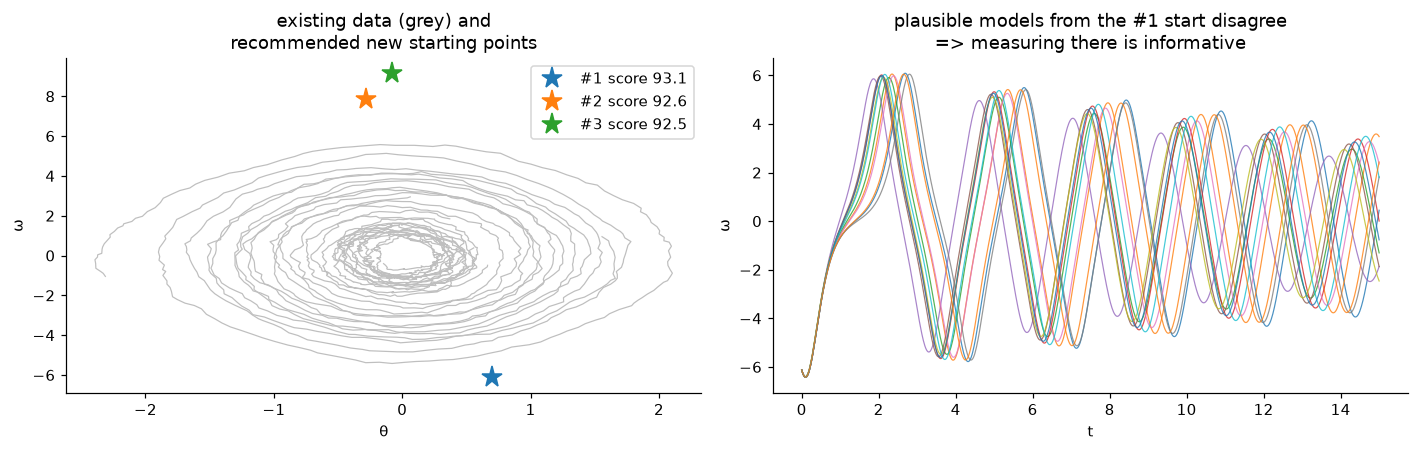

In [5]:
d = generate("pendulum", noise=0.05, noise_type="red", plot=False); m, D = load(d)
rhs = tb.fit_skeleton(m, D, {"theta": "omega", "omega": "-p0*sin(theta) - p1*omega"})["rhs"]
a = assess(m, D, rhs)
display(Markdown(brief_markdown(a)))
from eqdisc.assess import _rhs_with
from eqdisc import uq
coefs = uq.coefficient_uncertainty(m, D, rhs)["coefs"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for j in range(D["U"].shape[0]):
    axes[0].plot(D["U"][j, :, 0], D["U"][j, :, 1], color="0.75", lw=0.8)
ex = a["experiments"]["ranked"]
for i, e in enumerate(ex[:3]):
    axes[0].plot(*e["initial_condition"], "*", ms=14, color=f"C{i}", label=f"#{i+1} score {e['score']}")
axes[0].set(xlabel="θ", ylabel="ω", title="existing data (grey) and\nrecommended new starting points"); axes[0].legend()
rng = np.random.default_rng(0)
ic = ex[0]["initial_condition"]; t = D["t"]
for k in range(12):
    Y = solvers.integrate_ode(["theta", "omega"], _rhs_with(coefs, rng, 2.0), ic, t)
    axes[1].plot(t, Y[:, 1], lw=0.8, alpha=0.8)
Yd = solvers.integrate_ode(["theta", "omega"], _rhs_with(coefs, rng, 2.0), D["U"][-1, 0], t)
axes[1].set(xlabel="t", ylabel="ω", title="plausible models from the #1 start disagree\n=> measuring there is informative")
plt.tight_layout(); plt.show()

## 5.4 Human-in-the-loop
In an agent session (`python -m eqdisc.agent DATASET --human --context '...'`, or `run_agent(..., human=input)`), the agent

1. can call `ask_human` for things the data cannot tell it (is a quantity conserved by design? is a term physical?);
2. at submission, shows the scientist this brief (confidence, evidence, competing models, next experiments, questions);
3. the scientist replies `accept`, gives feedback, or supplies a new data file (`data: path/to/new_run.csv`). New data are ingested, appended and re-checked.

All exchanges are logged in the HTML report.